In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
metadata = pd.read_csv("../config/metadata.csv", index_col=0)

normalized_counts = pd.read_csv("../data/results/deseq2/normalized_counts.csv", index_col=0)
counts_t = normalized_counts.T

scaler = StandardScaler()
counts_scaled = scaler.fit_transform(counts_t)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(counts_scaled)

print(pca.explained_variance_ratio_)
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"], index=counts_t.index)


[0.49974437 0.16781228]


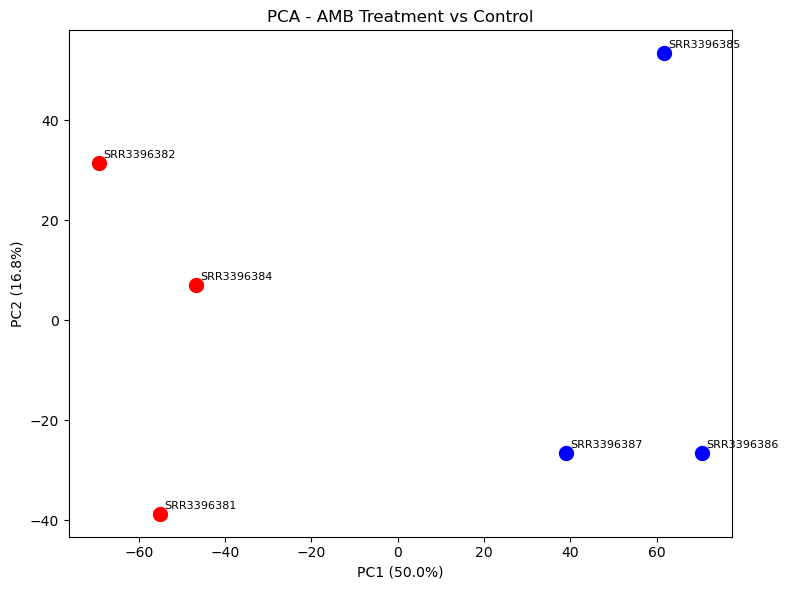

In [3]:
plt.figure(figsize=(8, 6))

for sample, row in pca_df.iterrows():
    condition = metadata.loc[sample, "condition"]
    color = "red" if condition == "treatment" else "blue"
    plt.scatter(row["PC1"], row["PC2"], color=color, s=100)
    plt.text(row["PC1"] + 1, row["PC2"] + 1, sample, fontsize=8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA - AMB Treatment vs Control")
plt.tight_layout()
#plt.savefig("../data/results/plots/PCA_plot.png", dpi=300, bbox_inches="tight")
#plt.show()

In [4]:
results = pd.read_csv("../data/results/deseq2/results.csv", index_col=0)
normalized_counts = pd.read_csv("../data/results/deseq2/normalized_counts.csv", index_col=0)
metadata = pd.read_csv("../config/metadata.csv", index_col=0)
results_clean = results.dropna(subset=["padj", "log2FoldChange"]).copy()
results_clean["significant"] = (results_clean["padj"] < 0.05) & (abs(results_clean["log2FoldChange"]) > 1)

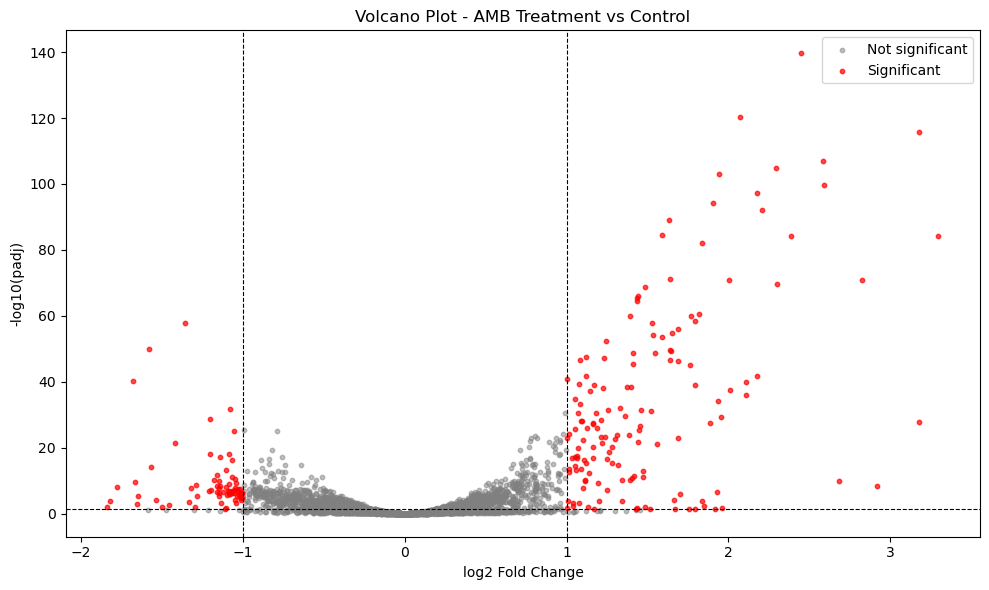

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(results_clean[~results_clean["significant"]]["log2FoldChange"],
            -np.log10(results_clean[~results_clean["significant"]]["padj"]),
            color="grey", alpha=0.5, s=10, label="Not significant")

plt.scatter(results_clean[results_clean["significant"]]["log2FoldChange"],
            -np.log10(results_clean[results_clean["significant"]]["padj"]),
            color="red", alpha=0.7, s=10, label="Significant")

plt.axhline(y=-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=1, color="black", linestyle="--", linewidth=0.8)
plt.axvline(x=-1, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")
plt.title("Volcano Plot - AMB Treatment vs Control")
plt.legend()
plt.tight_layout()
plt.savefig("../data/results/plots/volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
top_genes = results_clean[results_clean["significant"]].nsmallest(50, "padj").index
heatmap_data = normalized_counts.loc[top_genes]
heatmap_data_log = np.log2(heatmap_data + 1)

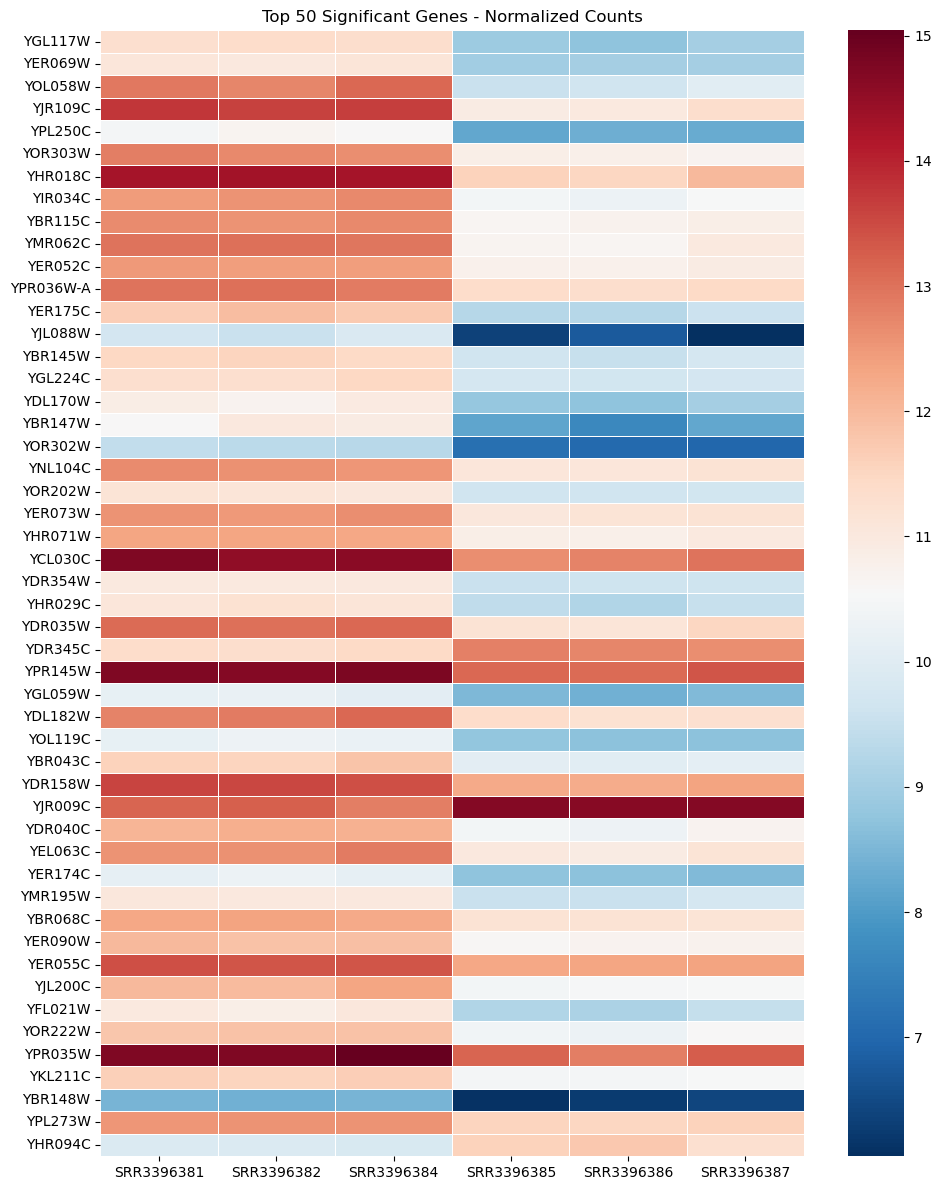

In [24]:
plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data_log, 
            cmap="RdBu_r",
            yticklabels=True,
            xticklabels=True,
            linewidths=0.5,
            linecolor="white")
plt.title("Top 50 Significant Genes - Normalized Counts")
plt.tight_layout()
plt.savefig("../data/results/plots/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
